In [63]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import numpy
import datetime
import pandas as pd
import numpy as np
import json

In [64]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [65]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)

In [66]:
# Definir data/hora de lançamento (necessário para modelos dependentes do tempo)
import datetime
# Limpar qualquer configuração pré-existente de modelo atmosférico que possa causar re-execução automática
for attr in ("atmospheric_model_type", "atmospheric_model_file", "atmospheric_model_dict"):
    if hasattr(env, attr):
        try:
            setattr(env, attr, None)
        except Exception:
            pass
# usar data atual
env.set_date(datetime.datetime.now())
print('Launch date set to', env.datetime_date)


Launch date set to 2026-07-24 18:15:04.973259+00:00


In [67]:
# GFS  Global Forecast System
#env.set_atmospheric_model(type="Forecast", file="GFS")
env.set_atmospheric_model(type="standard_atmosphere")

In [68]:
# motor

motor_data = pd.read_csv("motor_data_pronto.csv")

In [69]:
print("DataFrame columns:", motor_data.columns)
if 'Unnamed: 0' in motor_data.columns:
    motor_data = motor_data.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")
    print("Updated DataFrame columns:", motor_data.columns)

# Check for duplicate time values in the first column and remove them
if motor_data.iloc[:, 0].duplicated().any():
    print("Duplicate time values found in the thrust curve data. Removing duplicates.")
    motor_data = motor_data.drop_duplicates(subset=[motor_data.columns[0]])


# Select only the 'Time(s)' and 'Thrust(N)' columns and get the values as a NumPy array
thrust_source_array = motor_data[['Time(s)', 'Thrust(N)']].values


# Now, use the NumPy array as the thrust source to initialize SolidMotor
Dedalo_motor = SolidMotor(
    thrust_source=thrust_source_array, # Use the NumPy array
    dry_mass= 1.86,
    dry_inertia=(0.04718349, 0.04718349, 0.00178498),
    nozzle_radius=0.020715,
    grain_number=3,
    grain_density=1750,
    grain_outer_radius=0.0315,
    grain_initial_inner_radius=0.010,
    grain_initial_height=0.116,
    grain_separation=0,
    grains_center_of_mass_position=0.174, 
    center_of_dry_mass_position=0.24, # verificar
    nozzle_position=-0.05, 
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=0.008,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

print("\nSolidMotor initialized successfully!")

DataFrame columns: Index(['Time(s)', 'Thrust(N)'], dtype='str')

SolidMotor initialized successfully!


Nozzle Details
Nozzle Radius: 0.020715 m
Nozzle Throat Radius: 0.008 m

Grain Details
Number of Grains: 3
Grain Spacing: 0 m
Grain Density: 1750 kg/m3
Grain Outer Radius: 0.0315 m
Grain Inner Radius: 0.01 m
Grain Height: 0.116 m
Grain Volume: 0.000 m3
Grain Mass: 0.569 kg

Motor Details
Total Burning Time: 2.196 s
Total Propellant Mass: 1.707 kg
Structural Mass Ratio: 0.521
Average Propellant Exhaust Velocity: 126.972 m/s
Average Thrust: 98.702 N
Maximum Thrust: 179.741 N at 0.968 s after ignition.
Total Impulse: 216.750 Ns



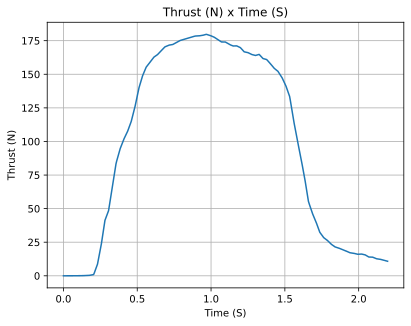

In [70]:
Dedalo_motor.info()

In [71]:
rocket_data = pd.read_json("dedalo_data.json", typ="series")

Rocket object created successfully!


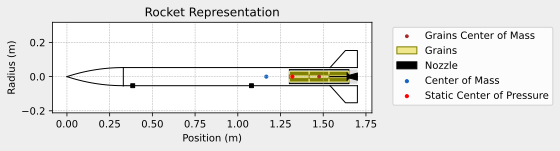

In [72]:
Dedalo_rocket = Rocket(
    radius = rocket_data["radius"],
    mass= rocket_data["mass"],
    power_off_drag="poweroff.csv",
    power_on_drag="poweron.csv",
    inertia= rocket_data["inertia"],
    center_of_mass_without_motor= rocket_data["center_of_mass_without_motor"],
    coordinate_system_orientation= rocket_data["coordinate_system_orientation"],
)

print("Rocket object created successfully!")
Dedalo_rocket.add_motor(Dedalo_motor, position=1.65)

nose_cone = Dedalo_rocket.add_nose(
    length=rocket_data["nose_length"], kind=rocket_data["nose_type"], position=rocket_data["nose_position"]
)


aletas = Dedalo_rocket.add_trapezoidal_fins(
    n = rocket_data["n_aletas"],
    root_chord= rocket_data["root_chord"],
    tip_chord= rocket_data["tip_chord"],
    span= rocket_data["span"],
    position= rocket_data["position"],
    cant_angle= rocket_data["cant_angle"]
)

rail_buttons = Dedalo_rocket.set_rail_buttons(
    upper_button_position=0.385,
    lower_button_position=1.08,
    angular_position=45,
)


#main = Dedalo_rocket.add_parachute(
#    name="main",
#    cd_s=1.5,
#    trigger="apogee",      # ejection altitude in meters
#    sampling_rate=105,
#    lag=1.5,
#    radius=0.6,
#    noise=(0, 8.3, 0.5),
#)
Dedalo_rocket.draw()

In [73]:
Dedalo_rocket.info()


Inertia Details

Rocket Mass: 4.900 kg (without motor)
Rocket Dry Mass: 6.760 kg (with unloaded motor)
Rocket Loaded Mass: 8.467 kg
Rocket Structural Mass Ratio: 0.798
Rocket Inertia (with unloaded motor) 11: 1.429 kg*m2
Rocket Inertia (with unloaded motor) 22: 1.429 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.013 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.053 m
Rocket Frontal Area: 0.008825 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.122 m
Rocket Center of Dry Mass - Nozzle Exit: 0.611 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.387 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.078 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 8.050/rad

Center of Pressure

Nose Co

In [74]:
Dedalo_flight = Flight(
    rocket=Dedalo_rocket, environment=env, rail_length=4, inclination=85, heading=0, verbose=True
    )

Current Simulation Time: 5.2877 s
>>> Simulation Completed at Time: 5.2779 s


In [75]:
Dedalo_flight.info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 478.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.923 | e1: 0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 315.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 1.439 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 1.156 s
Rail Departure Velocity: 8.284 m/s
Rail Departure Stability Margin: 1.851 c
Rail Departure Angle of Attack: 0.000°
Rail Departure Thrust-Weight Ratio: 2.351
Rail Departure Reynolds Number: 5.793e+04


Burn out State

Burn out time: 2.196 s
Altitude at burn out: 492.744 m (ASL) | 14.744 m (AGL)
Rocket speed at burn out: 10.047 m/s
Freestream velocity at 

In [35]:
Dedalo_flight.plots

In [ ]:
Dedalo_rocket.plots.static_margin()

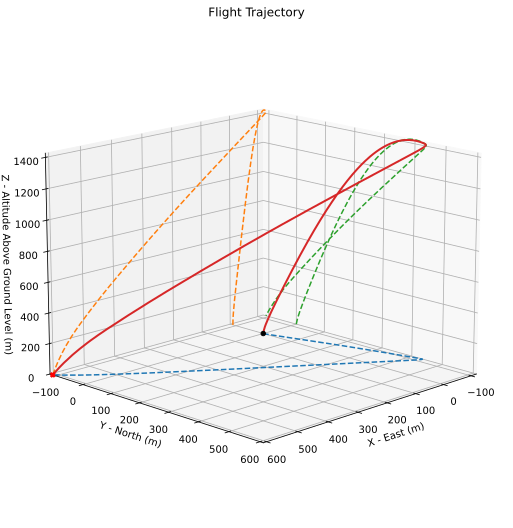

In [33]:
Dedalo_flight.plots.trajectory_3d()

In [ ]:
dedalo_data.json